# 01. RFP 데이터셋 EDA

**목표**: 100개 RFP 데이터의 구조·품질·분포를 파악하여 RAG 파이프라인 설계 근거를 마련한다.

데이터 출처: `data/metadata/data_list.csv` (본문 텍스트가 이미 추출되어 있음 → HWP 직접 파싱 불필요)

원본 문서: `data/raw/` (HWP 96 + PDF 4)
원본 문서에서 추출된 csv파일 형식의 데이터 = `data/metadata/` (.xlsx)

## 0. 초기 세팅 — 데이터셋 추출

`src/dataset_utill/extract.py` 의 `extract_dataset()` 로 압축파일을 `data/` 하위 폴더로 정리한다.

In [2]:
import sys
from pathlib import Path

# 노트북은 notebooks/ 에서 실행되므로 프로젝트 루트를 import 경로에 추가
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.dataset_utill import extract_dataset

# 코드잇 데이터셋 zip 경로 - 실제 경로에 따라 수정
ZIP_PATH = Path.home() / 'Downloads' / 'dataset (2).zip'

# 결과값이 저장된 딕셔너리를 result 변수에 저장
result = extract_dataset(
    ZIP_PATH,
    raw_dir=ROOT / 'data' / 'raw',
    metadata_dir=ROOT / 'data' / 'metadata',
)
print(f"문서 {result['documents']}개 -> data/raw,\n"
      f"메타데이터 {result['metadata']}개 -> data/metadata\n"
      f"(건너뜀 {result['skipped']})")

문서 100개 -> data/raw,
메타데이터 5개 -> data/metadata
(건너뜀 0)


각 데이터세트 data_list들은 내용이 전부 일치하는것을 확인하였다.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# data_list들이 중복인것을 확인하여 pandas 라이브러리를 사용하기 위해 csv파일 하나를 사용
df = pd.read_csv(ROOT / 'data' / 'metadata' / 'data_list.csv')
print('shape:', df.shape)
df.head(3)

shape: (100, 12)


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...


## 1. 기본 정보 & 결측치

In [5]:
print('컬럼:', list(df.columns))
print()
print('결측치:')
print(df.isna().sum())

컬럼: ['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일형식', '파일명', '텍스트']

결측치:
공고 번호        18
공고 차수        18
사업명           0
사업 금액         1
발주 기관         0
공개 일자         0
입찰 참여 시작일    26
입찰 참여 마감일     8
사업 요약         0
파일형식          0
파일명           0
텍스트           0
dtype: int64


## 2. 파일 형식 분포

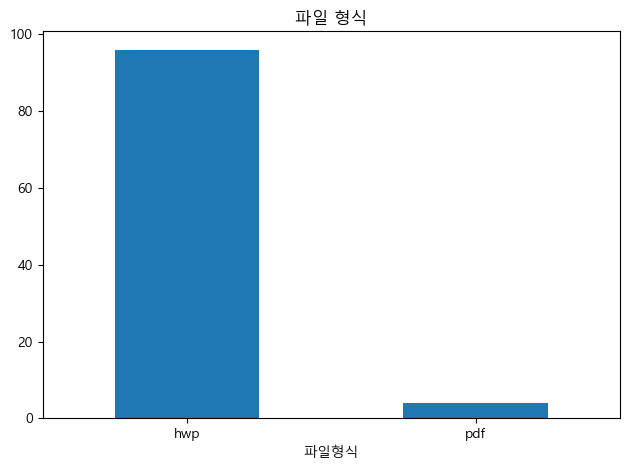

In [6]:
df['파일형식'].value_counts().plot.bar(title='파일 형식', rot=0)
plt.tight_layout(); plt.show()

## 3. 사업 금액 분포

count     99.00
mean       6.91
std       19.67
min        0.00
25%        0.70
50%        1.73
75%        4.06
max      141.07
Name: 사업 금액, dtype: float64 (단위: 억원)


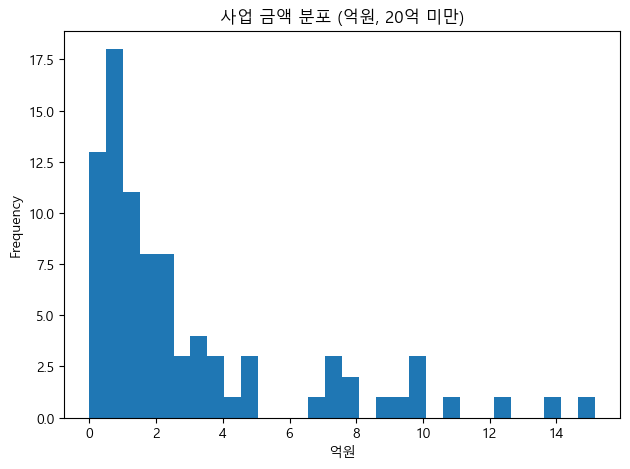

In [7]:
amt = pd.to_numeric(df['사업 금액'], errors='coerce').dropna()
print((amt / 1e8).describe().round(2), '(단위: 억원)')

# 0원/이상치 제외하고 분포 보기
amt[(amt > 0) & (amt < 2e9)].div(1e8).plot.hist(bins=30, title='사업 금액 분포 (억원, 20억 미만)')
plt.xlabel('억원'); plt.tight_layout(); plt.show()

## 4. 발주 기관

고유 기관 수: 87


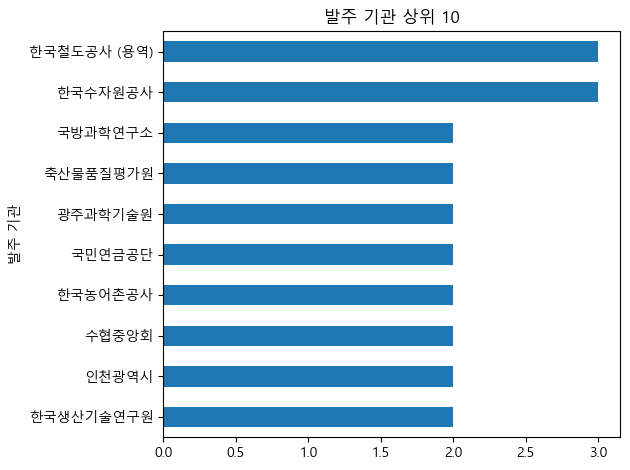

In [8]:
vc = df['발주 기관'].value_counts()
print('고유 기관 수:', vc.size)
vc.head(10).plot.barh(title='발주 기관 상위 10').invert_yaxis()
plt.tight_layout(); plt.show()

## 5. 날짜 분석 (공개일자 / 입찰 마감)

공개일자 범위: 2021-10-08 00:00:00 ~ 2025-02-11 13:32:46


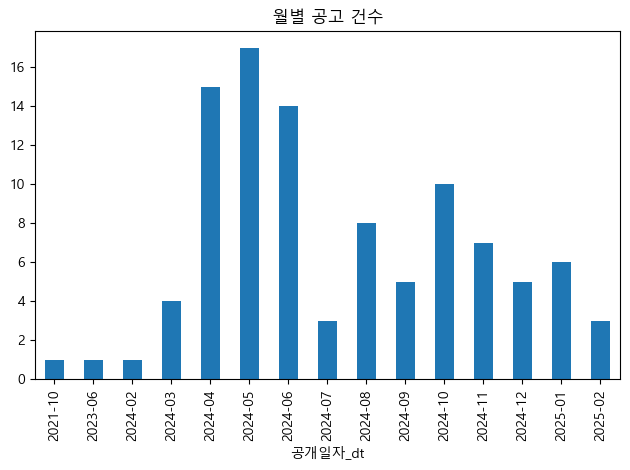

In [9]:
df['공개일자_dt'] = pd.to_datetime(df['공개 일자'], errors='coerce')
print('공개일자 범위:', df['공개일자_dt'].min(), '~', df['공개일자_dt'].max())
df['공개일자_dt'].dt.to_period('M').value_counts().sort_index().plot.bar(title='월별 공고 건수')
plt.tight_layout(); plt.show()

## 6. 본문 텍스트 품질 (가장 중요)

RFP는 보통 수십 페이지지만, 추출된 텍스트 길이 편차가 크다.
**짧은 문서는 추출이 불완전**하므로 RAG 품질에 직접 영향을 준다.

count      100.0
mean      3844.0
std       3693.0
min         89.0
25%       1198.0
50%       2583.0
75%       5842.0
max      18335.0
Name: 텍스트_길이, dtype: float64

500자 미만: 7건
1000자 미만: 21건
2000자 미만: 33건


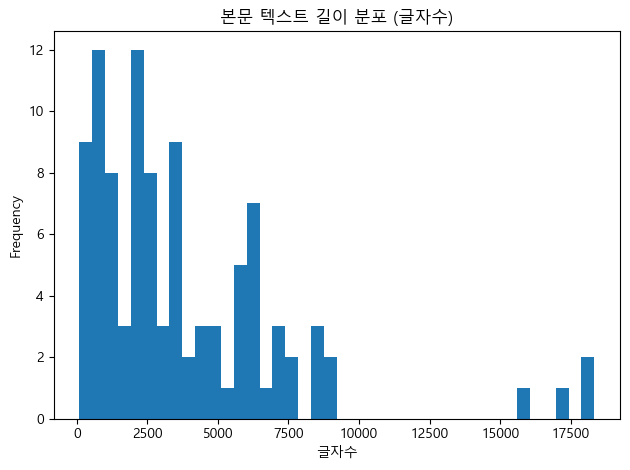

In [10]:
df['텍스트_길이'] = df['텍스트'].str.len()
print(df['텍스트_길이'].describe().round(0))
print()
for th in [500, 1000, 2000]:
    print(f'{th}자 미만: {(df["텍스트_길이"] < th).sum()}건')

df['텍스트_길이'].plot.hist(bins=40, title='본문 텍스트 길이 분포 (글자수)')
plt.xlabel('글자수'); plt.tight_layout(); plt.show()

In [11]:
# 추출이 빈약한 문서 목록 (1000자 미만) — 처리 방침 결정 대상
cols = ['사업명', '발주 기관', '파일형식', '텍스트_길이']
df[df['텍스트_길이'] < 1000][cols].sort_values('텍스트_길이')

,사업명,발주 기관,파일형식,텍스트_길이
18,2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역,한국발명진흥회 입찰공고,hwp,89
20,JST 공유대학(원) xAPI기반 LRS시스템 구축,전북대학교,hwp,130
17,2025 구미아시아육상경기선수권대회 종합정보시스템 및 홈페이지 등 구축 용역,2025 구미 아시아육상경기선수권대회 조직위원회,hwp,186
12,[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역,서울시립대학교,pdf,220
2,EIP3.0 고압가스 안전관리 시스템 구축 용역,한국생산기술연구원,hwp,234
8,스포츠윤리센터 LMS(학습지원시스템) 기능개선,재단법인스포츠윤리센터,hwp,298
49,사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보완 개발,국민연금공단,hwp,401
86,2024년 벤처확인종합관리시스템 기능 고도화 용역사업 입찰공고,(사)벤처기업협회,hwp,533
60,2024년도 평택시 버스정보시스템(BIS) 구축사업,경기도 평택시,hwp,536
78,IP-NAVI 해외지식재산센터 사업관리 시스템 기능개선,한국지식재산보호원,hwp,549


In [12]:
# 텍스트 샘플 직접 확인 (긴 문서 1개, 짧은 문서 1개)
longest = df.loc[df['텍스트_길이'].idxmax()]
shortest = df.loc[df['텍스트_길이'].idxmin()]
print('=== 가장 긴 문서 ===', longest['사업명'])
print(longest['텍스트'][:800])
print('\n=== 가장 짧은 문서 ===', shortest['사업명'])
print(shortest['텍스트'])

=== 가장 긴 문서 === 모바일오피스 시스템 고도화 용역(총체 및 1차)
  
 
제안요청서
모바일오피스 시스템 고도화
 
2024. 8.
 
담당
디지털융합본부
(디지털기술TF)
처장 이규범
TEL: 042-615-5730
FAX: 02-361-8371
E-MAIL: mineandy77@korail.com
부장 이정민
TEL: 042-615-5733
대리 조서연  
TEL: 042-615-5746
한국철도공사
 
 1. 사업 개요	  -   	1
 2. 운영 현황	  -   	2
 3. 사업 내용	  -   	4
 4. 사업추진 계획	  -   	6
 5. 제안요청 내용	  -   	7
 6. 제안서 작성요령	  -   	99
 7. 제안서 평가 및 선정 안내	  -   	105
 8. 보안 준수사항	  -   	124
 9. 기타사항	  -   	136
 10. 별지서식 및 붙임	  -   	 141
 
1
사업 개요
  사업목적
   (모바일 업무지원 확대) 모바일오피스 사용량 증가에 따른 사용자 편의성, 처리속도 개선 및 기능 강화로 모바일 업무지원 확대
   (서비스 연속성 확보) 시스템 사용요구에 대한 부하 분산으로 원활하고 안정적인 업무지원 서비스 제공
  사업개요
   사 업 명 : 모바일오피스 시스템 고도화
    ※ 본 사업은 소프트웨어 진흥법 제43조, 같은 법 시행령 제35조 내지 제37조, 소프트웨어사업 계약 및 관리감독에 관한 지침 제5조, 제6조에 따라 SW사업 영향평가를 미리 실시한 사업임(붙임 1)
    ※ 소프트웨어 진흥법 제50조에 따라 과업내용 확정을 위하여 과업심의위원회를 

=== 가장 짧은 문서 === 2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역
    
 
2024년 건설기술에 관한 특허-실용신안 활용실적 관리시스템 개편 용역 제안요청서
2024. 4.
   
 
기업성장지원실
 
부서명


## 7. EDA 결론 & 다음 단계
- 데이터 규모/형식: data_list.csv파일 내부에 텍스트가 추출되어있어서 원본 파일에서 텍스트를 따로 추출해줄 필요가 없다.
- 본문 텍스트 품질 이슈와 처리 방침(짧은 문서 제외 vs 원본 재파싱): 짧은 문서가 21건정도로 적은 문서 양이 아니기 때문에 원본 문서를 검토하여 데이터를 추가할 수 있는지 확인하여 보강을 진행한다.
